In [7]:
import pandas as pd
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# Load the data
data = pd.read_csv('new_dataset.csv')

# Count the number of rows in the data frame
num_rows = len(data)

# Display this count
print("Number of rows in the dataset: {}".format(num_rows))

# Information about the data frame
data.info()

# Display the first few rows of the data frame, sorted by the crash date in ascending order
data.sort_values(by='CRASH DATE').head().set_index('CRASH DATE')

Number of rows in the dataset: 2124643
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2124643 entries, 0 to 2124642
Data columns (total 10 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   CRASH DATE                     object 
 1   CRASH TIME                     object 
 2   NUMBER OF PERSONS INJURED      float64
 3   NUMBER OF PERSONS KILLED       float64
 4   NUMBER OF PEDESTRIANS INJURED  int64  
 5   NUMBER OF PEDESTRIANS KILLED   int64  
 6   NUMBER OF CYCLIST INJURED      int64  
 7   NUMBER OF CYCLIST KILLED       int64  
 8   NUMBER OF MOTORIST INJURED     int64  
 9   NUMBER OF MOTORIST KILLED      int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 162.1+ MB


,CRASH TIME,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED
CRASH DATE,,,,,,,,,
01/01/2013,22:07,0.0,0.0,0,0,0,0,0,0
01/01/2013,9:00,2.0,0.0,0,0,0,0,2,0
01/01/2013,17:50,1.0,0.0,0,0,0,0,1,0
01/01/2013,4:00,0.0,0.0,0,0,0,0,0,0
01/01/2013,5:20,1.0,0.0,0,0,0,0,1,0


In [8]:
# Convert 'CRASH DATE' and 'CRASH TIME' columns to datetime
data['CRASH DATE'] = pd.to_datetime(data['CRASH DATE'], errors='coerce')
data['CRASH TIME'] = pd.to_datetime(data['CRASH TIME'], format='%H:%M', errors='coerce').dt.time

# Define time intervals based on daily activities
time_intervals = {
    'Early Morning': (0, 5),
    'Morning': (5, 9),
    'School Hours': (9, 15),
    'Office Hours': (9, 17),
    'Afternoon': (15, 19),
    'Evening': (19, 24)
}

# Categorize each crash time into the defined intervals
def categorize_time(hour):
    for interval, (start, end) in time_intervals.items():
        if start <= hour < end:
            return interval
    return None

# Extract hour from CRASH TIME and apply categorization
data['Time Interval'] = data['CRASH TIME'].apply(lambda x: categorize_time(x.hour) if x else None)

# Group by 'Time Interval' and calculate total injuries and fatalities
time_interval_stats = data.groupby('Time Interval')[['NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED']].sum()

# Rename columns for clarity
time_interval_stats.columns = ['Injured', 'Killed']

# Display the statistics as a data frame
time_interval_stats


,Injured,Killed
Time Interval,,
Afternoon,90236.0,340.0
Early Morning,72041.0,741.0
Evening,155486.0,825.0
Morning,80284.0,450.0
Office Hours,87463.0,241.0
School Hours,187236.0,651.0


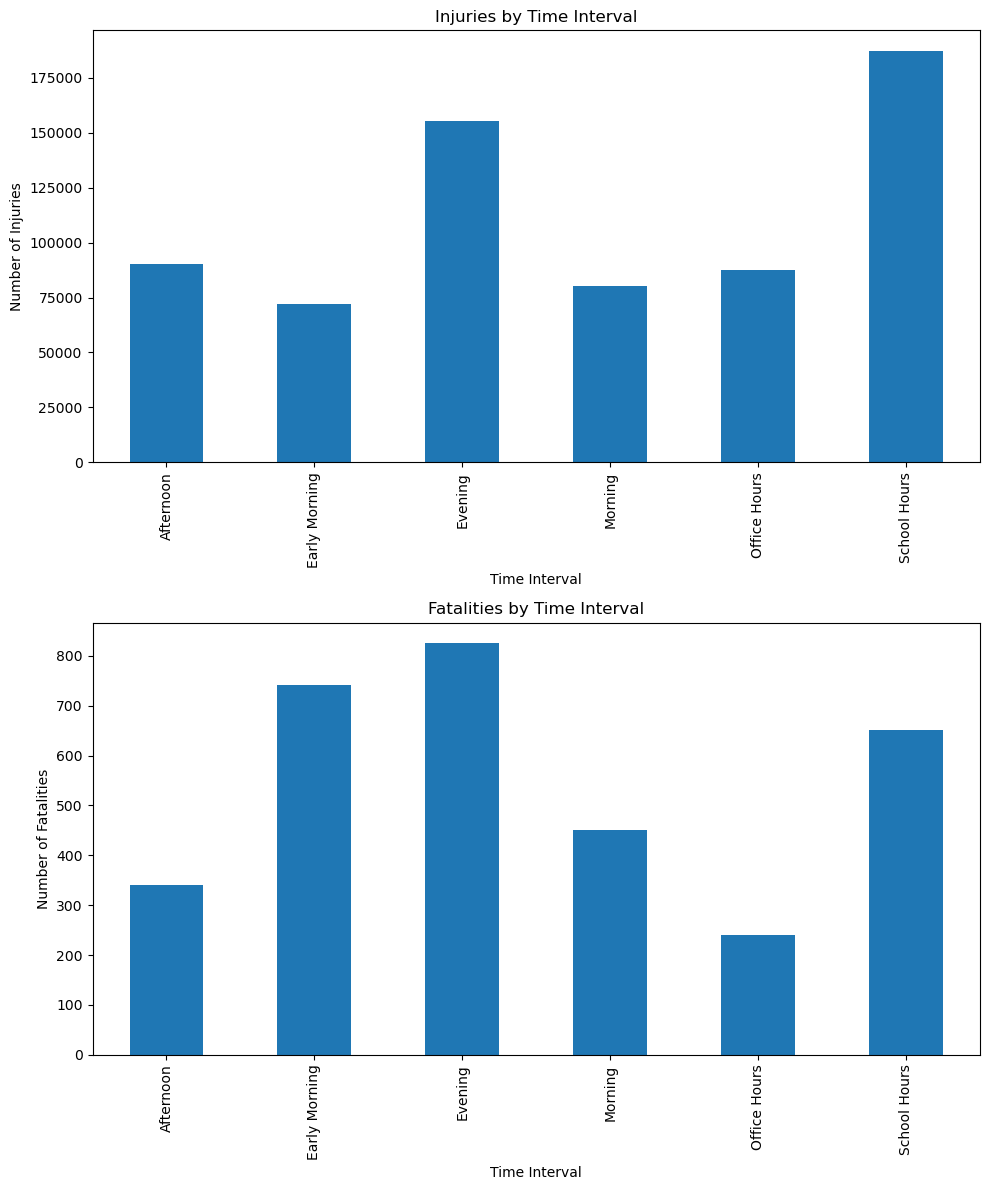

In [18]:
import matplotlib.pyplot as plt

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 12))

# Draw a bar plot for Injured
time_interval_stats['Injured'].plot(kind='bar', ax=axes[0], stacked=True)
axes[0].set_title('Injuries by Time Interval')
axes[0].set_xlabel('Time Interval')
axes[0].set_ylabel('Number of Injuries')

# Draw a bar plot for Killed
time_interval_stats['Killed'].plot(kind='bar', ax=axes[1], stacked=True)
axes[1].set_title('Fatalities by Time Interval')
axes[1].set_xlabel('Time Interval')
axes[1].set_ylabel('Number of Fatalities')

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

In [10]:
# Find the number of injured people in the data frame by year as an integer
injured = data.groupby('CRASH DATE')['NUMBER OF PERSONS INJURED'].sum()

# Find the number of killed people in the data frame by year as an integer
killed = data.groupby('CRASH DATE')['NUMBER OF PERSONS KILLED'].sum()

# Display the number of injured and killed people by year in the data frame
df = pd.DataFrame({'Injured': injured.astype(int), 'Killed': killed.astype(int)})

# The first column should be replaced with the year of the crash date
df.index = pd.to_datetime(df.index).year

# # If there are duplicate years, the values should be summed
df = df.groupby(df.index).sum()

# Display the first few rows of the updated data frame
df

,Injured,Killed
CRASH DATE,,
2012,27453,137
2013,55128,297
2014,51226,262
2015,51358,243
2016,60317,246
2017,60656,256
2018,61941,231
2019,61390,244
2020,44614,269


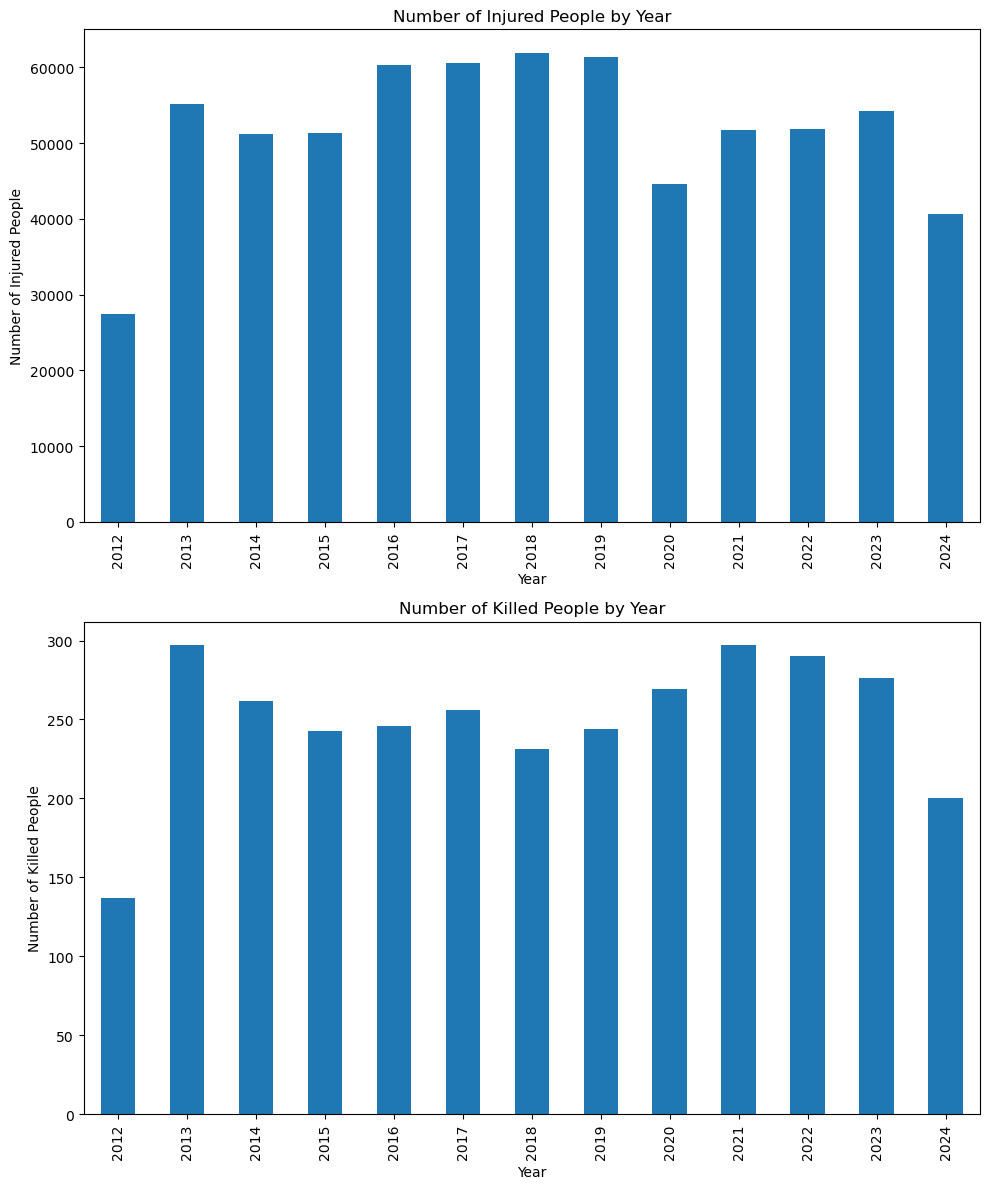

In [20]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 12))

# Plot Injured
df['Injured'].plot(kind='bar', ax=axes[0], legend=False)
axes[0].set_title('Number of Injured People by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Injured People')

# Plot Killed
df['Killed'].plot(kind='bar', ax=axes[1], legend=False)
axes[1].set_title('Number of Killed People by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Killed People')

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

In [12]:
import pandas as pd

# Data for NYC population from 2012 to 2024
data = {
    "Year": list(range(2012, 2025)),
    "Population": [
        8361000,  # 2012
        8399000,  # 2013
        8438000,  # 2014
        8468000,  # 2015
        8491000,  # 2016
        8538000,  # 2017
        8531000,  # 2018
        8337000,  # 2019
        8740000,  # 2020
        8463000,  # 2021
        8412000,  # 2022
        8260000,  # 2023
        8100000   # 2024
    ]
}

# Create DataFrame
nyc_population_df = pd.DataFrame(data)

# Display the DataFrame
nyc_population_df.set_index('Year')

,Population
Year,
2012,8361000
2013,8399000
2014,8438000
2015,8468000
2016,8491000
2017,8538000
2018,8531000
2019,8337000
2020,8740000


In [13]:
# Add the population data to the existing DataFrame
df['Population'] = nyc_population_df.set_index('Year')['Population']

# Display the updated DataFrame
df

,Injured,Killed,Population
CRASH DATE,,,
2012,27453,137,8361000
2013,55128,297,8399000
2014,51226,262,8438000
2015,51358,243,8468000
2016,60317,246,8491000
2017,60656,256,8538000
2018,61941,231,8531000
2019,61390,244,8337000
2020,44614,269,8740000
